<center> <img src = https://raw.githubusercontent.com/AndreyRysistov/DatasetsForPandas/main/hh%20label.jpg alt="drawing" style="width:400px;">

# <center> Проект: Анализ вакансий из HeadHunter
   

In [1]:
import pandas as pd
import psycopg2

# Юнит 3. Предварительный анализ данных

1. Напишите запрос, который посчитает количество вакансий в нашей базе (вакансии находятся в таблице vacancies). 

In [5]:
# текст запроса
query_1 = f'''
select count(*)
from vacancies
'''

In [7]:
df1 = pd.read_sql_query(query_1, connection)
df1

C:\Users\surko\AppData\Local\Temp\ipykernel_15680\2334675854.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df1 = pd.read_sql_query(query_1, connection)


,count
0,49197


2. Напишите запрос, который посчитает количество работодателей (таблица employers). 

In [10]:
query_2 = f'''
           select count(*)
           from employers
           '''

In [11]:
df2 = pd.read_sql_query(query_2, connection)
df2

C:\Users\surko\AppData\Local\Temp\ipykernel_15680\3988827909.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df2 = pd.read_sql_query(query_2, connection)


,count
0,23501


3. Посчитате с помощью запроса количество регионов (таблица areas).

In [12]:
query_3 = f'''
           select count(*)
           from areas
           '''

In [13]:
df3 = pd.read_sql_query(query_3, connection)
df3

C:\Users\surko\AppData\Local\Temp\ipykernel_15680\2507633428.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df3 = pd.read_sql_query(query_3, connection)


,count
0,1362


4. Посчитате с помощью запроса количество сфер деятельности в базе (таблица industries).

In [14]:
query_4 = f'''
           select count(*)
           from industries
           '''

In [15]:
df4 = pd.read_sql_query(query_4, connection)
df4

C:\Users\surko\AppData\Local\Temp\ipykernel_15680\2465840605.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df4 = pd.read_sql_query(query_4, connection)


,count
0,294


***

- Общее количество вакансий - 49197
- Общее количество работодателей - 23501
- Общее количество регионов - 1362
- Общее количество сфер деятельности - 294

# Юнит 4. Детальный анализ вакансий

1. Напишите запрос, который позволит узнать, сколько (cnt) вакансий в каждом регионе (area).
Отсортируйте по количеству вакансий в порядке убывания.

In [25]:
query_5 = f'''
           select
                 a.name as region,
                 count(v.id) as vacancies_count
           from vacancies v
           join areas a on a.id=v.area_id
           group by a.name
           order by vacancies_count desc
           limit 5
           '''

In [26]:
df5 = pd.read_sql_query(query_5, connection)
df5

C:\Users\surko\AppData\Local\Temp\ipykernel_15680\916639809.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df5 = pd.read_sql_query(query_5, connection)


,region,vacancies_count
0,Москва,5333
1,Санкт-Петербург,2851
2,Минск,2112
3,Новосибирск,2006
4,Алматы,1892


2. Напишите запрос, чтобы определить у какого количества вакансий заполнено хотя бы одно из двух полей с зарплатой.

In [27]:
query_6 = f'''
           select 
                 count(*) as vacancies_with_salary
           from vacancies
           where salary_from is not null
               or salary_to is not null
           '''

In [29]:
df6 = pd.read_sql_query(query_6, connection)
df6

C:\Users\surko\AppData\Local\Temp\ipykernel_15680\514211356.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df6 = pd.read_sql_query(query_6, connection)


,vacancies_with_salary
0,24073


3. Найдите средние значения для нижней и верхней границы зарплатной вилки. Округлите значения до целого.

In [30]:
query_7 = f'''
           select 
                 round(AVG(v.salary_from)) as avg_salary_from,
                 round(AVG(v.salary_to)) as avg_salary_to
           from vacancies v
           '''

In [31]:
df7 = pd.read_sql_query(query_7, connection)
df7

C:\Users\surko\AppData\Local\Temp\ipykernel_15680\2962255986.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df7 = pd.read_sql_query(query_7, connection)


,avg_salary_from,avg_salary_to
0,71065.0,110537.0


4. Напишите запрос, который выведет количество вакансий для каждого сочетания типа рабочего графика (schedule) и типа трудоустройства (employment), используемого в вакансиях. Результат отсортируйте по убыванию количества.

In [32]:
query_8 = f'''
           select 
                 v.schedule,
                 v.employment,
                 count(*) as vacansies_count
           from vacancies v
           group by v.schedule, v.employment
           order by vacansies_count desc
           '''

In [33]:
df8 = pd.read_sql_query(query_8, connection)
df8

C:\Users\surko\AppData\Local\Temp\ipykernel_15680\4125204554.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df8 = pd.read_sql_query(query_8, connection)


,schedule,employment,vacansies_count
0,Полный день,Полная занятость,35367
1,Удаленная работа,Полная занятость,7802
2,Гибкий график,Полная занятость,1593
3,Удаленная работа,Частичная занятость,1312
4,Сменный график,Полная занятость,940
5,Полный день,Стажировка,569
6,Вахтовый метод,Полная занятость,367
7,Полный день,Частичная занятость,347
8,Гибкий график,Частичная занятость,312
9,Полный день,Проектная работа,141


5. Напишите запрос, выводящий значения поля Требуемый опыт работы (experience) в порядке возрастания количества вакансий, в которых указан данный вариант опыта. 

In [34]:
query_9 = f'''
           select 
                v.experience,
                count(*) as vacansies_count
           from vacancies v
           group by v.experience
           order by vacansies_count asc
           '''

In [35]:
df9 = pd.read_sql_query(query_9, connection)
df9

C:\Users\surko\AppData\Local\Temp\ipykernel_15680\1294842566.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df9 = pd.read_sql_query(query_9, connection)


,experience,vacansies_count
0,Более 6 лет,1337
1,Нет опыта,7197
2,От 3 до 6 лет,14511
3,От 1 года до 3 лет,26152


***

Выводы:
- основное кодичество вакансий в больших городах
- только в половине вакансий есть указание на зарплату
- разброс зарплатной вилки от 71 тыс до 110 тыс
- в основном  ребуется полный рабочий день и полная занятость, также полнеый рабочий день и удаленная работа
- в основном требуетмся опыт работы от года, но есиь вакансии где опыт работы не требуется

# Юнит 5. Анализ работодателей

1. Напишите запрос, который позволит узнать, какие работодатели находятся на первом и пятом месте по количеству вакансий.

In [13]:
query_10 = f'''
           select 
                e.name,
                count(v.id) as vacancies_count
           from employers e
           join vacancies v on e.id=v.employer_id
           group by e.name
           order by vacancies_count desc
           limit 5
           '''

In [14]:
df10 = pd.read_sql_query(query_10, connection)
df10

C:\Users\surko\AppData\Local\Temp\ipykernel_10100\2676187490.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df10 = pd.read_sql_query(query_10, connection)


,name,vacancies_count
0,Яндекс,1933
1,Ростелеком,491
2,Тинькофф,444
3,СБЕР,428
4,Газпром нефть,331


2. Напишите запрос, который для каждого региона выведет количество работодателей и вакансий в нём.
Среди регионов, в которых нет вакансий, найдите тот, в котором наибольшее количество работодателей.


In [31]:
query_11 = f'''
           select 
                a.name,
                count(e.id) as emploers_count,
                count(v.id) as vacancies_count
           from areas a
           left join employers e on e.area=a.id
           left join vacancies v on a.id=v.area_id
           group by a.name
           having count(v.id)=0
           order by emploers_count desc
           limit 1
           '''

In [32]:
df11 = pd.read_sql_query(query_11, connection)
df11

C:\Users\surko\AppData\Local\Temp\ipykernel_10100\2499898655.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df11 = pd.read_sql_query(query_11, connection)


,name,emploers_count,vacancies_count
0,Россия,410,0


3. Для каждого работодателя посчитайте количество регионов, в которых он публикует свои вакансии. Отсортируйте результат по убыванию количества.


In [48]:
query_12 = f'''
           select 
                e.name,
                count(distinct v.area_id) as areas_count
           from employers e
           join vacancies v on e.id=v.employer_id
           group by e.name
           order by areas_count desc
           '''

In [49]:
df12 = pd.read_sql_query(query_12, connection)
df12

C:\Users\surko\AppData\Local\Temp\ipykernel_10100\2869452552.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df12 = pd.read_sql_query(query_12, connection)


,name,areas_count
0,Яндекс,181
1,Ростелеком,152
2,Спецремонт,116
3,Поляков Денис Иванович,88
4,ООО ЕФИН,71
...,...,...
14761,UniSol,1
14762,UNISTORY LLC,1
14763,UNIT6,1
14764,United Distribution,1


4. Напишите запрос для подсчёта количества работодателей, у которых не указана сфера деятельности. 

In [58]:
query_13 = f'''
           select 
                count(e.id) 
           from employers e
           left join employers_industries ei on e.id=ei.employer_id
           where ei.industry_id is null
           '''

In [59]:
df13 = pd.read_sql_query(query_13, connection)
df13

C:\Users\surko\AppData\Local\Temp\ipykernel_10100\2040699062.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df13 = pd.read_sql_query(query_13, connection)


,count
0,8419


5. Напишите запрос, чтобы узнать название компании, находящейся на третьем месте в алфавитном списке (по названию) компаний, у которых указано четыре сферы деятельности. 

In [64]:
query_14 = f'''
           select
                e.name
           from employers e
           join employers_industries ei on e.id=ei.employer_id
           group by e.name
           having count(ei.industry_id) = 4
           order by e.name
           '''

In [65]:
df14 = pd.read_sql_query(query_14, connection)
df14

C:\Users\surko\AppData\Local\Temp\ipykernel_10100\3173977645.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df14 = pd.read_sql_query(query_14, connection)


,name
0,101 Интернет
1,21vek.by
2,2ГИС
3,2К
4,4 пикселя +
...,...
1131,ЮРИОН
1132,ЮТИП Технологии
1133,ЯКласс
1134,ЯрНео


6. С помощью запроса выясните, у какого количества работодателей в качестве сферы деятельности указана Разработка программного обеспечения.


In [68]:
query_15 = f'''
           select
                count(ei.employer_id) as employer
           from employers_industries ei
           join industries i on ei.industry_id=i.id
           where i.name = 'Разработка программного обеспечения'
           '''

In [69]:
df15 = pd.read_sql_query(query_15, connection)
df15

C:\Users\surko\AppData\Local\Temp\ipykernel_10100\29850896.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df15 = pd.read_sql_query(query_15, connection)


,employer
0,3553


7. Для компании «Яндекс» выведите список регионов-миллионников, в которых представлены вакансии компании, вместе с количеством вакансий в этих регионах. Также добавьте строку Total с общим количеством вакансий компании. Результат отсортируйте по возрастанию количества.

Список городов-милионников надо взять [отсюда](https://ru.wikipedia.org/wiki/%D0%93%D0%BE%D1%80%D0%BE%D0%B4%D0%B0-%D0%BC%D0%B8%D0%BB%D0%BB%D0%B8%D0%BE%D0%BD%D0%B5%D1%80%D1%8B_%D0%A0%D0%BE%D1%81%D1%81%D0%B8%D0%B8). 

Если возникнут трудности с этим задание посмотрите материалы модуля  PYTHON-17. Как получать данные из веб-источников и API. 

In [70]:
query_15 = f'''
           SELECT 
                 a.name AS city,
                 COUNT(v.id) AS vacancies_count
           from vacancies v
           JOIN employers e ON v.employer_id = e.id
           JOIN areas a ON v.area_id = a.id
           WHERE e.name = 'Яндекс'
           AND a.name IN (
                          'Москва', 'Санкт-Петербург', 'Новосибирск', 'Екатеринбург',
                          'Казань', 'Красноярск', 'Нижний Новгород', 'Челябинск',
                          'Уфа', 'Краснодар', 'Самара', 'Ростов-на-Дону',
                           'Омск', 'Воронеж', 'Пермь', 'Волгоград'
                          )
           GROUP BY a.name

           UNION ALL

           SELECT 
                 'Total' AS city,
               COUNT(v.id) AS vacancies_count
           FROM vacancies v
           JOIN employers e ON v.employer_id = e.id
           JOIN areas a ON v.area_id = a.id
           WHERE e.name = 'Яндекс'
           AND a.name IN (
                          'Москва', 'Санкт-Петербург', 'Новосибирск', 'Екатеринбург',
                          'Казань', 'Красноярск', 'Нижний Новгород', 'Челябинск',
                          'Уфа', 'Краснодар', 'Самара', 'Ростов-на-Дону',
                          'Омск', 'Воронеж', 'Пермь', 'Волгоград'
                         )
           ORDER BY vacancies_count ASC;
           '''

In [71]:
df15 = pd.read_sql_query(query_15, connection)
df15

C:\Users\surko\AppData\Local\Temp\ipykernel_10100\29850896.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df15 = pd.read_sql_query(query_15, connection)


,city,vacancies_count
0,Омск,21
1,Челябинск,22
2,Красноярск,23
3,Волгоград,24
4,Пермь,25
5,Казань,25
6,Ростов-на-Дону,25
7,Уфа,26
8,Самара,26
9,Краснодар,30


***

Выводы:
- Основное работодатели на рынке большие корпорации
- есть регионы в котроых нет вакансий
- у некоторых работодателей есть вакансии в разных регионах
- компании указывают несколько сфер деятельности, но есть работодатели который не указывают сферу деятельности
- более 3 тыс вакансий разработчиков
- 

# Юнит 6. Предметный анализ

1. Сколько вакансий имеет отношение к данным?

Считаем, что вакансия имеет отношение к данным, если в её названии содержатся слова 'data' или 'данн'.

*Подсказка: Обратите внимание, что названия вакансий могут быть написаны в любом регистре.* 


In [92]:
query_16 = f'''
           select
                count(*) as data_vacancies_count
           from vacancies
           where name ilike '%data%' or name ilike '%данн%'
           '''

In [93]:
df16 = pd.read_sql_query(query_16, connection)
df16

C:\Users\surko\AppData\Local\Temp\ipykernel_10100\2384761779.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df16 = pd.read_sql_query(query_16, connection)


,data_vacancies_count
0,1771


2. Сколько есть подходящих вакансий для начинающего дата-сайентиста? 
Будем считать вакансиями для дата-сайентистов такие, в названии которых есть хотя бы одно из следующих сочетаний:
* 'data scientist'
* 'data science'
* 'исследователь данных'
* 'ML' (здесь не нужно брать вакансии по HTML)
* 'machine learning'
* 'машинн%обучен%'

** В следующих заданиях мы продолжим работать с вакансиями по этому условию.*

Считаем вакансиями для специалистов уровня Junior следующие:
* в названии есть слово 'junior' *или*
* требуемый опыт — Нет опыта *или*
* тип трудоустройства — Стажировка.
 

In [94]:
query_17 = f'''
           select
                count(*) as datajun_vacancies_count
           from vacancies
           where 
          (
              name ilike '%data scientist%'
              or name ilike '%data science%'
              or name ilike '%исследователь данных%'
              or (name ilike '%ml%' and name not ilike'%html%')
              or name ilike '%machine learning%'
              or name ilike '%машинн%обучен%'
          )
           AND
           (
             name ilike '%junior%'
             or experience = 'Нет опыта'
             or employment = 'Стажировка'
           )
           '''

In [95]:
df17 = pd.read_sql_query(query_17, connection)
df17

C:\Users\surko\AppData\Local\Temp\ipykernel_10100\734475077.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df17 = pd.read_sql_query(query_17, connection)


,datajun_vacancies_count
0,51


3. Сколько есть вакансий для DS, в которых в качестве ключевого навыка указан SQL или postgres?

** Критерии для отнесения вакансии к DS указаны в предыдущем задании.*

In [7]:
query_18 = f'''
           select
                count(*) as datajun_vacancies_count
           from vacancies
           where 
          (
              name ilike '%data scientist%'
              or name ilike '%data science%'
              or name ilike '%исследователь данных%'
              or (name ilike '%ml%' and name not ilike'%html%')
              or name ilike '%machine learning%'
              or name ilike '%машинн%обучен%'
          )
           AND
           (
             key_skills ilike '%sql%'
             or key_skills ilike '%postgress%'
           )
           '''

In [8]:
df18 = pd.read_sql_query(query_18, connection)
df18

C:\Users\surko\AppData\Local\Temp\ipykernel_8360\2128909004.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df18 = pd.read_sql_query(query_18, connection)


,datajun_vacancies_count
0,229


4. Проверьте, насколько популярен Python в требованиях работодателей к DS.Для этого вычислите количество вакансий, в которых в качестве ключевого навыка указан Python.

** Это можно сделать помощью запроса, аналогичного предыдущему.*

In [9]:
query_19 = f'''
           select
                count(*) as datajun_vacancies_count
           from vacancies
           where 
          (
              name ilike '%data scientist%'
              or name ilike '%data science%'
              or name ilike '%исследователь данных%'
              or (name ilike '%ml%' and name not ilike'%html%')
              or name ilike '%machine learning%'
              or name ilike '%машинн%обучен%'
          )
           AND
           (
             key_skills ilike '%python%'
           )
           '''

In [10]:
df19 = pd.read_sql_query(query_19, connection)
df19

C:\Users\surko\AppData\Local\Temp\ipykernel_8360\1607568420.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df19 = pd.read_sql_query(query_19, connection)


,datajun_vacancies_count
0,357


5. Сколько ключевых навыков в среднем указывают в вакансиях для DS?
Ответ округлите до двух знаков после точки-разделителя.

In [ ]:
query_20 = f'''
           select
               round(avg(cardinality(string_to_array(key_skills, chr(9)))),2)
                as avg_skills_count
           from vacancies 
           where 
          (
              name ilike '%data scientist%'
              or name ilike '%data science%'
              or name ilike '%исследователь данных%'
              or (name ilike '%ml%' and name not ilike'%html%')
              or name ilike '%machine learning%'
              or name ilike '%машинн%обучен%'
          ) 
           '''

In [56]:
df20 = pd.read_sql_query(query_20, connection)
df20

C:\Users\surko\AppData\Local\Temp\ipykernel_8360\3937512139.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df20 = pd.read_sql_query(query_20, connection)


,avg_skills_count
0,6.55


6. Напишите запрос, позволяющий вычислить, какую зарплату для DS в **среднем** указывают для каждого типа требуемого опыта (уникальное значение из поля *experience*). 

При решении задачи примите во внимание следующее:
1. Рассматриваем только вакансии, у которых заполнено хотя бы одно из двух полей с зарплатой.
2. Если заполнены оба поля с зарплатой, то считаем зарплату по каждой вакансии как сумму двух полей, делённую на 2. Если заполнено только одно из полей, то его и считаем зарплатой по вакансии.
3. Если в расчётах участвует null, в результате он тоже даст null (посмотрите, что возвращает запрос select 1 + null). Чтобы избежать этой ситуацию, мы воспользуемся функцией [coalesce](https://postgrespro.ru/docs/postgresql/9.5/functions-conditional#functions-coalesce-nvl-ifnull), которая заменит null на значение, которое мы передадим. Например, посмотрите, что возвращает запрос `select 1 + coalesce(null, 0)`

Выясните, на какую зарплату в среднем может рассчитывать дата-сайентист с опытом работы от 3 до 6 лет. Результат округлите до целого числа. 

In [ ]:
query_21 = f'''
           select round(AVG(COALESCE((salary_from + salary_to) / 2, salary_from, salary_to)))
           from vacancies 
           where 
          (
              name ilike '%data scientist%'
              or name ilike '%data science%'
              or name ilike '%исследователь данных%'
              or (name ilike '%ml%' and name not ilike'%html%')
              or name ilike '%machine learning%'
              or name ilike '%машинн%обучен%'
          ) 
          and experience = 'От 3 до 6 лет'
          and key_skills is not null
           '''

In [80]:
df21 = pd.read_sql_query(query_21, connection)
df21

C:\Users\surko\AppData\Local\Temp\ipykernel_8360\4160601219.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df21 = pd.read_sql_query(query_21, connection)


,round
0,248674.0


***

выводы:
- проанализировна 1771 вакансия где имеетсЯ упоминание о данных
- из них всего 51 вакансия для начинающих без опыта
- в среднем нужно знать 6 ключевых навыков, наиболее важные знание SQL и python
- средняя зарплата специалиста DS 240 тыс

# Общий вывод по проекту


1. Выводы по рынку труда

В базе данных представлено большое количество вакансий, однако рынок труда распределён неравномерно. Наибольшее число вакансий сосредоточено в крупных городах, прежде всего в Москве и Санкт-Петербурге. 

Большое количество вакансий присутствует и в других городах-миллионниках, что говорит о постепенном развитии региональных рынков труда.

2. Выводы по работодателям

Наибольшее число вакансий публикуют крупные компании. Это банки, IT-компании, телекоммуникационные организации и крупные промышленные предприятия.

Они имеют одну или несколько сфер деятельности, однако некоторые не указывает отрасль работы.

Крупные работодатели размещают вакансии одновременно в нескольких регионах, это говорит о расширеннии рынка труда на периферию.

3. Выводы по вакансиям, связанным с анализом данных

Количество вакансий, связанных с анализом данных и Data Science, меньше общего рынка труда. Это подтверждает, что Data Science остаётся относительно узкой, но востребованной областью.

4. Выводы по начинающим специалистам Data Science

Количество вакансий для начинающих специалистов значительно уступает числу вакансий для специалистов среднего и высокого уровня.

Работодатели чаще заинтересованы в сотрудниках, уже обладающих практическим опытом работы. 

5. Выводы по ключевым навыкам

В вакансиях для Data Scientist работодатели указывают несколько обязательных компетенций одновременно. Наиболее востребованными являются: Python, SQL.

6. Выводы по заработной плате

Уровень заработной платы напрямую зависит от опыта работы.


Общий вывод

Проведённый анализ показал, что российский рынок труда характеризуется высокой концентрацией вакансий в крупных городах и у крупных работодателей. Направление Data Science демонстрирует спрос и привлекательный уровень заработной платы, однако предъявляет высокие требования к квалификации специалистов.


# Дополнительные исследования

## Анализ основных навыков DS

In [12]:
query_22 = f'''
           select key_skills
           from vacancies 
           where 
          (
              name ilike '%data scientist%'
              or name ilike '%data science%'
              or name ilike '%исследователь данных%'
              or (name ilike '%ml%' and name not ilike'%html%')
              or name ilike '%machine learning%'
              or name ilike '%машинн%обучен%'
          )
          and key_skills is not null 
           '''

In [13]:
df_skills = pd.read_sql_query(query_22, connection)

C:\Users\surko\AppData\Local\Temp\ipykernel_15304\401475158.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_skills = pd.read_sql_query(query_22, connection)


In [20]:
# Создаём пустой список для хранения всех навыков
skills = []

# Проходим по всем строкам с навыками
for row in df_skills['key_skills']:
    skills.extend(row.split('\t'))

# Преобразуем список навыков в объект Series
skills_series = pd.Series(skills)

# Подсчитываем количество упоминаний каждого навыка
# и выбираем 10 наиболее популярных
top_skills = skills_series.value_counts().head(10)

top_skills

Python                       354
SQL                          208
Machine Learning             114
Git                           81
Математическая статистика     62
Data Analysis                 55
Linux                         53
Pandas                        52
Data Science                  52
ML                            49
Name: count, dtype: int64

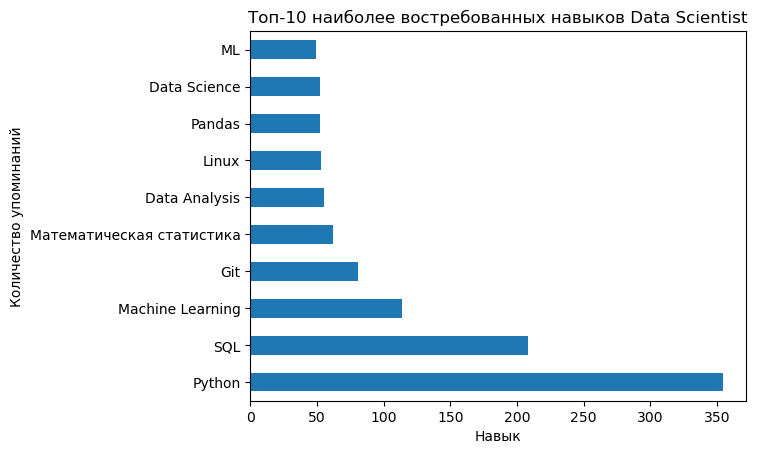

In [23]:
import matplotlib.pyplot as plt

# Строим столбчатую диаграмму
top_skills.plot(kind='barh')

# Добавляем заголовок и подписи осей
plt.title('Топ-10 наиболее востребованных навыков Data Scientist')
plt.xlabel('Навык')
plt.ylabel('Количество упоминаний')

plt.show()

Проведённый анализ показал, что работодатели предъявляют к специалистам по Data Science комплексные требования, сочетающие навыки программирования, анализа данных и машинного обучения, а также знание git и математической статистики.

## Анализ зарплаты специалистов DS

In [28]:
query_23 = f'''
           select 
                 experience,
                 round(AVG(COALESCE((salary_from + salary_to) / 2, salary_from, salary_to)))
           from vacancies 
           where 
          (
              name ilike '%data scientist%'
              or name ilike '%data science%'
              or name ilike '%исследователь данных%'
              or (name ilike '%ml%' and name not ilike'%html%')
              or name ilike '%machine learning%'
              or name ilike '%машинн%обучен%'
          )
          and key_skills is not null
          group by experience
           '''

In [29]:
df_salary = pd.read_sql_query(query_23, connection)


C:\Users\surko\AppData\Local\Temp\ipykernel_15304\2408738727.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_salary = pd.read_sql_query(query_23, connection)


,experience,round
0,Более 6 лет,157933.0
1,Нет опыта,74643.0
2,От 1 года до 3 лет,150909.0
3,От 3 до 6 лет,248674.0


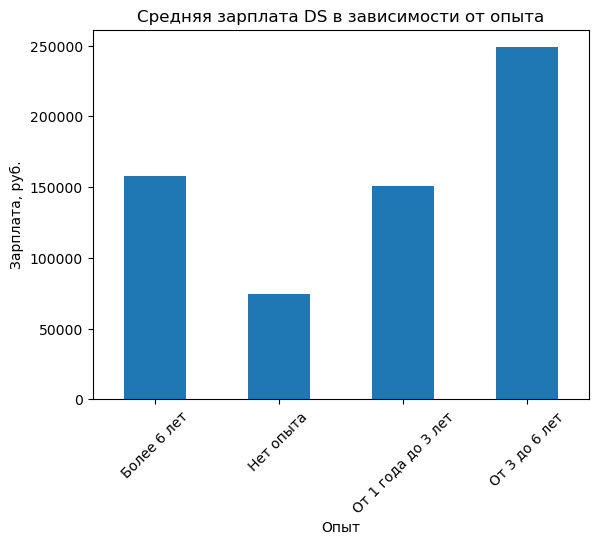

In [30]:
df_salary.plot(
    x='experience',
    y='round',
    kind='bar',
    legend=False
)

plt.title('Средняя зарплата DS в зависимости от опыта')
plt.xlabel('Опыт')
plt.ylabel('Зарплата, руб.')
plt.xticks(rotation=45)

plt.show()

Так же можно провести исследования о вакансиях на других платформах

In [31]:
connection.close()